# M14 · Encoders & Contrastive Training — Hands-on, Step by Tiny Step

**Companion to lesson M14. Written for someone new to ML.**

Where do the embeddings from M11–M13 come from? **Encoders** turn raw text into vectors, and
**contrastive training** teaches them **which pairs should be close and which should separate**.
This is the bridge from "understands language" to "retrieves the right item."

**What you'll build (every step has an analogy, a tiny numeric trace, logging, and a picture):**
- **Part A · Encoders & the loss:** what a **sentence encoder** actually does
  (text → tokens → **pool** → **normalize**), **dual (= two-tower) vs cross-encoder**, how a
  cross-encoder is **actually used** (retrieve → rerank), **InfoNCE + temperature**, and
  **in-batch negatives** as an explicit score **matrix**.
- **Part B · Hard negatives & fine-tuning:** **triplet loss**, why hard negatives raise the
  gradient, the **real hard-negative mining pipeline**, and an end-to-end **fine-tuning recipe**.

Libraries: **PyTorch + scikit-learn + matplotlib** — all preinstalled in Colab. Run each cell
with **Shift+Enter**.

## Step 1 · Setup + synthetic data

Queries and their matched items share a hidden **topic + individual taste**, so a positive pair
should score high. We reuse this data throughout.

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from sklearn.metrics import roc_auc_score
torch.manual_seed(0)
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"

rng = np.random.default_rng(0)
D_raw, T = 24, 100
tcent = rng.normal(0, 1, (T, D_raw)) * 2.0                    # many topic centers
def make(n, seed):
    r = np.random.default_rng(seed)
    tp = r.integers(0, T, n)
    taste = r.normal(0, 1, (n, D_raw)) * 0.7                  # individual taste, shared query<->item
    base = tcent[tp] + taste
    q = base + r.normal(0, 0.35, (n, D_raw)); i = base + r.normal(0, 0.35, (n, D_raw))
    return torch.tensor(q, dtype=torch.float32), torch.tensor(i, dtype=torch.float32), tp
Q, I, tpq = make(6000, 1)
Qte, Ite, tpt = make(1500, 2)
print("data ready:", len(Q), "train pairs,", len(Qte), "test pairs,", T, "topics")

data ready: 6000 train pairs, 1500 test pairs, 100 topics


---
# Part A · Encoders & the contrastive objective

## Step 2 · What a "sentence encoder" actually does

An **encoder** turns text into **one vector**. But a transformer outputs **one vector per
token**, not one per sentence. The step that collapses many token vectors into a single
sentence vector is **pooling**. The full pipeline is four moves:

```
text     "senior data scientist role"
  |  (1) TOKENIZE          -> split into (sub)word tokens
tokens   [senior, data, scientist, role]
  |  (2) TRANSFORMER       -> each token becomes a contextual vector
vectors  [.9,.1,0,.1] [.2,.9,.1,0] [.3,.8,.2,.1] [.2,.6,.3,.1]
  |  (3) POOL (mean)       -> average the token vectors into ONE
pooled   [.54, .81, .20, .10]
  |  (4) L2-NORMALIZE      -> length 1, so dot product == cosine
vector   the sentence embedding  (this is what M11 stores, M13 indexes)
```

We fake the transformer with a tiny hand-made vocab so you can watch every number. Real
encoders learn these token vectors — the **pool + normalize** recipe is identical.

encode the QUERY:
  tokens: ['senior', 'data', 'scientist', 'role']
    senior    -> [0.9 0.1 0.  0.1]
    data      -> [0.2 0.9 0.1 0. ]
    scientist -> [0.3 0.8 0.2 0.1]
    role      -> [0.2 0.6 0.3 0.1]
  mean pool     -> [0.4   0.6   0.15  0.075]
  normalized    -> [0.54  0.81  0.203 0.101]  (length 1.0 )

cos(query, A='hiring senior data scientist') = 0.970   <- shares 'senior data scientist'
cos(query, B='junior engineer remote role')  = 0.835   <- fewer shared tokens


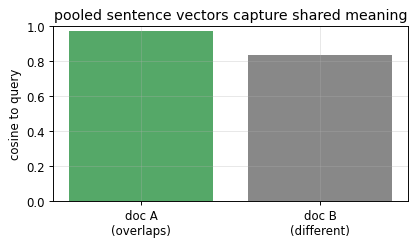

In [5]:
# a tiny toy "transformer output": each known word -> a 4-dim vector
vocab = {
 "senior":[0.9,0.1,0.0,0.1], "data":[0.2,0.9,0.1,0.0], "scientist":[0.3,0.8,0.2,0.1],
 "hiring":[0.1,0.2,0.9,0.1], "remote":[0.0,0.1,0.2,0.9], "role":[0.2,0.6,0.3,0.1],
 "junior":[0.6,0.1,0.0,0.5], "engineer":[0.4,0.7,0.2,0.1],
}
vocab = {k: np.array(v) for k, v in vocab.items()}

def sentence_encode(text, log=False):
    toks = [t for t in text.lower().split() if t in vocab]         # (1) tokenize
    vecs = np.array([vocab[t] for t in toks])                      # (2) per-token vectors
    pooled = vecs.mean(0)                                          # (3) MEAN POOL
    vec = pooled / np.linalg.norm(pooled)                          # (4) L2 normalize
    if log:
        print("  tokens:", toks)
        for t in toks: print(f"    {t:10}-> {vocab[t]}")
        print("  mean pool     ->", pooled.round(3))
        print("  normalized    ->", vec.round(3), " (length", round(np.linalg.norm(vec),3), ")")
    return vec

print("encode the QUERY:"); q = sentence_encode("senior data scientist role", log=True)
A = sentence_encode("hiring senior data scientist")
B = sentence_encode("junior engineer remote role")
print(f"\ncos(query, A='hiring senior data scientist') = {q@A:.3f}   <- shares 'senior data scientist'")
print(f"cos(query, B='junior engineer remote role')  = {q@B:.3f}   <- fewer shared tokens")

plt.figure(figsize=(5,3)); plt.bar(["doc A\n(overlaps)","doc B\n(different)"], [q@A, q@B], color=[GREEN, GRAY])
plt.ylabel("cosine to query"); plt.ylim(0,1); plt.title("pooled sentence vectors capture shared meaning"); plt.show()

### The transformer step, unpacked — **self-attention**

Step (2) above just said "each token becomes a contextual vector" — here is *how*, because the
cross-encoder in Step 4 reuses the exact same mechanism. That step is **self-attention**.
Definition first, then numbers:

> **Self-attention** gives each token a **new vector** that is a **weighted average of all the
> tokens in the sentence**, where each weight says *how much this token should pay attention to
> that one*. For one token: **(a)** measure its similarity (dot product) to every token;
> **(b)** softmax those into weights that sum to 1 (those weights are the "attention");
> **(c)** new vector = Σ weight · token. **"self"** = the tokens attend to **each other** (same
> sentence); **"full"** = **every** token does this, so they **all** update.

We watch one token attend, then all of them. (Real transformers first multiply each token by
learned **Query/Key/Value** matrices; here those are the identity, so the weight is just the
plain dot product — same idea.)

In [7]:
def selfattn_softmax(z): z = np.array(z, float); z = z - z.max(); e = np.exp(z); return e / e.sum()

# 2-D tokens so every number is visible (dim0 = "remote-ness", dim1 = "data-ness")
Stoks = {"remote": np.array([1.,0.]), "data": np.array([0.,1.]), "onsite": np.array([-1.,0.])}
names = list(Stoks); M = np.array([Stoks[n] for n in names])
print("tokens:", {n: Stoks[n].tolist() for n in names}, "\n")

print("ONE token, 'remote', attends to ALL tokens:")
sims = [M[0] @ M[j] for j in range(len(names))]             # (a) similarity to every token
print("  (a) dot(remote, each) =", np.round(sims, 2), "for tokens", names)
w = selfattn_softmax(sims)                                  # (b) softmax -> attention weights
print("  (b) softmax -> weights =", w.round(3), " (sum = 1)")
new_remote = (w[:, None] * M).sum(0)                        # (c) weighted blend of all tokens
print("  (c) new 'remote' = sum(weight * token) =", new_remote.round(3), " (was [1, 0])")

print("\nFULL self-attention = repeat for EVERY token, so they ALL update:")
for i, n in enumerate(names):
    wi = selfattn_softmax([M[i] @ M[j] for j in range(len(names))])
    print(f"   {n:7} weights {wi.round(2)} -> new {(wi[:, None] * M).sum(0).round(3)}")
print("\nA transformer stacks many such layers; THEN pool + normalize (above) -> sentence vector.")

tokens: {'remote': [1.0, 0.0], 'data': [0.0, 1.0], 'onsite': [-1.0, 0.0]} 

ONE token, 'remote', attends to ALL tokens:
  (a) dot(remote, each) = [ 1.  0. -1.] for tokens ['remote', 'data', 'onsite']
  (b) softmax -> weights = [0.665 0.245 0.09 ]  (sum = 1)
  (c) new 'remote' = sum(weight * token) = [0.575 0.245]  (was [1, 0])

FULL self-attention = repeat for EVERY token, so they ALL update:
   remote  weights [0.67 0.24 0.09] -> new [0.575 0.245]
   data    weights [0.21 0.58 0.21] -> new [0.    0.576]
   onsite  weights [0.09 0.24 0.67] -> new [-0.575  0.245]

A transformer stacks many such layers; THEN pool + normalize (above) -> sentence vector.


### E5 and IRPS — real sentence encoders

The toy above is exactly how real ones work, with two additions:

- **E5** (a popular open encoder) is a transformer trained **contrastively** on query–passage
  pairs, then **mean-pooled + normalized**. Its trick: prepend a **role prefix** —
  `"query: ..."` for the search text and `"passage: ..."` for documents — because retrieval is
  **asymmetric** (a short question vs a long answer) and the prefix tells the model which side
  it is encoding.
- **IRPS** is LinkedIn's in-house retrieval/sentence encoder: same **transformer → pool →
  normalize** recipe, trained contrastively but tuned on LinkedIn data and tasks.

We simulate the E5 prefix effect: the **same words** get a slightly different vector depending
on whether they are encoded as a query or a passage.

In [9]:
# simulate role prefixes: a tiny additive "query:" vs "passage:" bias vector
qpref = np.array([0.10, 0.00, -0.05, 0.00])
ppref = np.array([-0.05, 0.05, 0.10, 0.00])
def encode_with_role(text, role):
    base = np.array([vocab[t] for t in text.lower().split() if t in vocab]).mean(0)
    base = base + (qpref if role == "query" else ppref)          # role prefix shifts the vector
    return base / np.linalg.norm(base)
same = "senior data scientist"
as_q = encode_with_role(same, "query"); as_p = encode_with_role(same, "passage")
print(f"'{same}' as QUERY   -> {as_q.round(3)}")
print(f"'{same}' as PASSAGE -> {as_p.round(3)}")
print(f"cosine(query-form, passage-form) = {as_q@as_p:.3f}  (close, but NOT identical)")
print("-> the same text encodes differently by role; that's what the E5 prefix buys you.")

'senior data scientist' as QUERY   -> [0.683 0.723 0.06  0.08 ]
'senior data scientist' as PASSAGE -> [0.521 0.812 0.25  0.083]
cosine(query-form, passage-form) = 0.965  (close, but NOT identical)
-> the same text encodes differently by role; that's what the E5 prefix buys you.


## Step 3 · Dual (two-tower) encoder vs cross-encoder

Two shapes for scoring a (query, item) pair:

- **Dual encoder** — embeds query and item **separately**; score = dot product. **This is the
  same thing as the "two-tower" (or "bi-encoder", or "Siamese") model from M12** — two names for
  one architecture. Because the item vector depends on the **item alone**, it can be
  **precomputed & indexed** → perfect for **first-stage retrieval** (M12/M13).
- **Cross-encoder** — reads the **pair together** (query and item tokens attend across each
  other), so it can compare exact phrases. **More accurate**, but the score depends on **both**
  inputs at once, so there is **no standalone item vector to store** → must run **once per pair**.

We train both on match/no-match pairs and compare **pair accuracy (AUC)** on **hard**
(same-topic) pairs.

pair-match AUC on HARD (same-topic) pairs:  dual (two-tower) 0.626   cross-encoder 0.721
dual: embed once, index, ANN-search millions.  cross: O(pairs) -> rerank hundreds only.


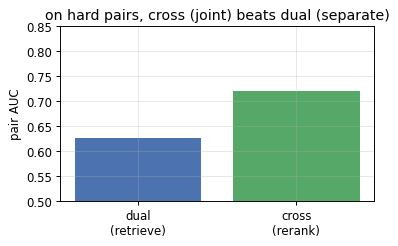

In [11]:
def pairs(Qs, Is, tp, seed):
    r = np.random.default_rng(seed); n = len(Qs); neg = np.zeros(n, dtype=int)
    for j in range(n):                                    # HARD negative: a same-topic different item
        cand = np.where(tp == tp[j])[0]; cand = cand[cand != j]
        neg[j] = r.choice(cand) if len(cand) else j
    qi = torch.cat([Qs, Qs]); ii = torch.cat([Is, Is[neg]])
    y  = torch.cat([torch.ones(n), torch.zeros(n)])
    return qi, ii, y
qtr, itr, ytr = pairs(Q, I, tpq, 1); qte, ite, yte = pairs(Qte, Ite, tpt, 2)
bce = nn.BCEWithLogitsLoss()

class Tower(nn.Module):                                    # one side of a DUAL (two-tower) encoder
    def __init__(self): super().__init__(); self.net = nn.Sequential(nn.Linear(D_raw,32), nn.ReLU(), nn.Linear(32,16))
    def forward(self, x): return self.net(x)
qT, iT = Tower(), Tower(); opt = torch.optim.Adam(list(qT.parameters())+list(iT.parameters()), lr=0.01)
for _ in range(80):
    opt.zero_grad(); bce((qT(qtr)*iT(itr)).sum(1), ytr).backward(); opt.step()
dual_auc = roc_auc_score(yte.numpy(), ((qT(qte)*iT(ite)).sum(1)).detach().numpy())

class Cross(nn.Module):                                    # reads the PAIR jointly
    def __init__(self): super().__init__(); self.net = nn.Sequential(nn.Linear(D_raw*3,64), nn.ReLU(), nn.Linear(64,1))
    def forward(self, q, i): return self.net(torch.cat([q, i, q*i], 1)).squeeze(1)
cx = Cross(); opt = torch.optim.Adam(cx.parameters(), lr=0.005)
for _ in range(80):
    opt.zero_grad(); bce(cx(qtr, itr), ytr).backward(); opt.step()
cross_auc = roc_auc_score(yte.numpy(), cx(qte, ite).detach().numpy())

print(f"pair-match AUC on HARD (same-topic) pairs:  dual (two-tower) {dual_auc:.3f}   cross-encoder {cross_auc:.3f}")
plt.figure(figsize=(4.6,3)); plt.bar(["dual\n(retrieve)","cross\n(rerank)"], [dual_auc, cross_auc], color=[BLUE, GREEN])
plt.ylim(0.5,0.85); plt.ylabel("pair AUC"); plt.title("on hard pairs, cross (joint) beats dual (separate)"); plt.show()
print("dual: embed once, index, ANN-search millions.  cross: O(pairs) -> rerank hundreds only.")

## Step 4 · Inside a cross-encoder — how the "score" is actually produced

The word "score" hides the whole trick, so let's open it up. A cross-encoder does **not** make
two vectors and compare them. It makes **one** sequence, runs the **self-attention from Step 2**
over it, and reads **one number** off a small head. Four moves:

```
(1) GLUE query + doc into ONE token sequence:
      [CLS]  data  scientist  hiring  data  scientist
      (CLS = a summary slot; a real model also inserts a [SEP] boundary token)

(2) SELF-ATTENTION over the whole sequence (the SAME mechanism as Step 2):
    EVERY token attends to EVERY token, so ALL tokens update -- including the
    QUERY tokens attending to the DOC tokens. That cross-looking is the "interaction".

(3) READ OUT one vector -- the [CLS] position (or a pool of all tokens):
    it has now absorbed a blend of query AND doc.

(4) A linear HEAD (learned weight w, bias b) turns that one vector into ONE number:
      score = w . readout + b
```

The key: there is **no reusable "doc vector."** The readout — and therefore the score —
**depends on query and doc together**. Change the doc → self-attention produces different token
vectors → the readout changes → the score changes. Below we run the **full** Step-2
self-attention (all tokens update), then read the `[CLS]` position.

In [13]:
xvocab = {
 "data":[0.2,0.9,0.1,0.0], "scientist":[0.3,0.8,0.2,0.1],
 "hiring":[0.1,0.2,0.9,0.1], "remote":[0.0,0.1,0.2,0.9],
 "sales":[0.7,0.1,0.1,0.2], "role":[0.2,0.6,0.3,0.1],
}
xvocab = {k: np.array(v) for k, v in xvocab.items()}
def xsoftmax(z): z = z - z.max(); e = np.exp(z); return e/e.sum()
w_head = np.array([0.2, 1.0, -0.3, -0.2]); b_head = -0.1        # the learned scoring head

def cross_score(query, doc, show=False):
    qtok, dtok = query.split(), doc.split()
    seq_words = ["[CLS]"] + qtok + dtok                        # (1) ONE glued sequence ([SEP] omitted)
    cls0 = np.mean([xvocab[t] for t in qtok], axis=0)          # [CLS] starts as the query summary
    V = np.array([cls0] + [xvocab[t] for t in qtok] + [xvocab[t] for t in dtok])
    new = np.zeros_like(V)                                     # (2) FULL self-attention: EVERY token
    for i in range(len(V)):                                    #     attends to EVERY token -> all update
        a = xsoftmax(V[i] @ V.T)
        new[i] = (a[:, None] * V).sum(0)
    readout = new[0]                                           # (3) read the [CLS] position
    score = w_head @ readout + b_head                          # (4) linear head -> ONE number
    if show:
        print(f"  sequence: {seq_words}")
        for word, o in zip(seq_words, new):
            print(f"     {word:11}-> {o.round(3)}")
        print(f"  read [CLS] = {readout.round(3)}")
        print(f"  score = w . [CLS] + b = {score:.3f}\n")
    return score

print("QUERY = 'data scientist'\n")
print("DOC A = 'hiring data scientist' (has the query terms):")
sA = cross_score("data scientist", "hiring data scientist", show=True)
print("DOC B = 'remote sales role' (unrelated):")
sB = cross_score("data scientist", "remote sales role", show=True)
print(f"score(A)={sA:.3f} > score(B)={sB:.3f}: EVERY token updated (not just [CLS]); the doc's")
print("tokens reshaped the whole sequence, so the [CLS] readout -- and the score -- differ.")
print("A dual encoder can't do this: its doc vector is built with no view of the query.")

QUERY = 'data scientist'

DOC A = 'hiring data scientist' (has the query terms):
  sequence: ['[CLS]', 'data', 'scientist', 'hiring', 'data', 'scientist']
     [CLS]      -> [0.233 0.779 0.232 0.055]
     data       -> [0.233 0.783 0.227 0.054]
     scientist  -> [0.232 0.774 0.238 0.056]
     hiring     -> [0.213 0.683 0.342 0.064]
     data       -> [0.233 0.783 0.227 0.054]
     scientist  -> [0.232 0.774 0.238 0.056]
  read [CLS] = [0.233 0.779 0.232 0.055]
  score = w . [CLS] + b = 0.645

DOC B = 'remote sales role' (unrelated):
  sequence: ['[CLS]', 'data', 'scientist', 'remote', 'sales', 'role']
     [CLS]      -> [0.269 0.64  0.174 0.166]
     data       -> [0.267 0.648 0.174 0.16 ]
     scientist  -> [0.27  0.631 0.174 0.172]
     remote     -> [0.239 0.489 0.18  0.321]
     sales      -> [0.3   0.54  0.171 0.217]
     role       -> [0.269 0.613 0.175 0.187]
  read [CLS] = [0.269 0.64  0.174 0.166]
  score = w . [CLS] + b = 0.508

score(A)=0.645 > score(B)=0.508: EVERY token u

### The same, fully by hand (2-D, so you can check every number)

To see *exactly* where the score comes from, here it is with tiny **2-D** tokens —
**dim0 = "remote-ness", dim1 = "data-ness"** — and a head `w=[1,0]` that just reads
"is remote present?". Query = `"remote data"`. Full self-attention, every token printed.

In [15]:
tok2 = {"remote":np.array([1.,0.]), "data":np.array([0.,1.]),
        "onsite":np.array([-1.,0.]), "analyst":np.array([0.,1.])}
w2 = np.array([1.,0.]); b2 = 0.0                              # head reads dim0 = remote signal

def cross_by_hand(query_words, doc_words):
    seq  = ["[CLS]"] + query_words + doc_words
    cls0 = np.mean([tok2[t] for t in query_words], axis=0)    # [CLS] starts as mean of query tokens
    V = np.array([cls0] + [tok2[t] for t in query_words] + [tok2[t] for t in doc_words])
    new = np.zeros_like(V)                                    # FULL self-attention: all tokens update
    for i in range(len(V)):
        logits = V[i] @ V.T                                   # similarity of token i to every token
        a = np.exp(logits - logits.max()); a = a / a.sum()    # softmax -> attention weights
        new[i] = (a[:, None] * V).sum(0)                      # new token = weighted blend
    readout = new[0]; score = w2 @ readout + b2               # read [CLS], head -> ONE number
    print(f"  query={query_words}  doc={doc_words}")
    for word, o in zip(seq, new):
        print(f"     {word:8}-> {o.round(3)}")
    print(f"  read [CLS] = {readout.round(3)}   score = w.[CLS] + b = {score:.3f}\n")
    return score

print("DOC A = 'remote data analyst' (contains remote):")
a = cross_by_hand(["remote","data"], ["remote","data","analyst"])
print("DOC B = 'onsite data' (onsite = opposite of remote):")
b = cross_by_hand(["remote","data"], ["onsite","data"])
print(f"score(A)={a:.3f} > score(B)={b:.3f}")
print("the doc's remote/onsite token flows through self-attention into EVERY token including")
print("[CLS], shifting dim0, so the head reads a different number. No two vectors compared.")

DOC A = 'remote data analyst' (contains remote):
  query=['remote', 'data']  doc=['remote', 'data', 'analyst']
     [CLS]   -> [0.417 0.583]
     remote  -> [0.621 0.379]
     data    -> [0.239 0.761]
     remote  -> [0.621 0.379]
     data    -> [0.239 0.761]
     analyst -> [0.239 0.761]
  read [CLS] = [0.417 0.583]   score = w.[CLS] + b = 0.417

DOC B = 'onsite data' (onsite = opposite of remote):
  query=['remote', 'data']  doc=['onsite', 'data']
     [CLS]   -> [0.259 0.572]
     remote  -> [0.471 0.419]
     data    -> [0.091 0.689]
     onsite  -> [-0.36   0.405]
     data    -> [0.091 0.689]
  read [CLS] = [0.259 0.572]   score = w.[CLS] + b = 0.259

score(A)=0.417 > score(B)=0.259
the doc's remote/onsite token flows through self-attention into EVERY token including
[CLS], shifting dim0, so the head reads a different number. No two vectors compared.


## Step 5 · WHERE you use a cross-encoder — retrieve → rerank

Because scoring needs the pair together (Step 4), a cross-encoder is **too slow to search from
millions** — but perfect to **rerank** a short list. It's always the **last stage**, behind a
cheap retriever. The scale arithmetic forces this design:

```
10M docs, one query:
  cross-encoder on ALL 10M   -> 10M x ~8ms  = ~22 HOURS/query   (impossible)
  dual encoder + ANN         -> ~10 ms -> top ~100 candidates    (fast, rough order)
  cross-encoder on those 100 -> 100 x ~8ms = ~0.8 s              (affordable, precise)
```

So the real pipeline is two stages:

```
query -> [STAGE 1: dual encoder + ANN] -> top-K candidates (fast, from the whole corpus)
      -> [STAGE 2: cross-encoder]       -> re-score each (query, candidate) jointly, re-sort
      -> return the top few
```

**Real places this is used:** search reranking (web/job/product), **RAG** (rerank retrieved
passages before the LLM reads them), question answering, recommendation reranking, and pairwise
tasks like dedup / entity matching. Rule of thumb: **use a cross-encoder whenever you have a
small set of pairs and want maximum accuracy** — i.e. the rerank stage after a dual encoder
pre-filters. Each test query's **true match is its own paired item**; we retrieve the top-K with
the dual encoder, then **rerank** those K with the cross-encoder, and watch the true item get
pulled toward rank 1 — measured by **MRR** (mean reciprocal rank) and **hit@1**.

query 7: true item rank  ->  dual retrieval: 10   after cross rerank: 4

over 600 queries:
  retrieve-only : MRR 0.052   hit@1 0.015
  + cross rerank: MRR 0.280   hit@1 0.213   <- true item pulled toward the top


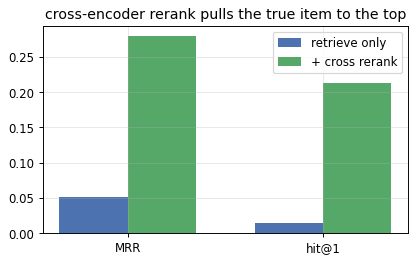

In [17]:
with torch.no_grad():
    ITE = iT(Ite); QTE = qT(Qte)                    # STAGE-0: precompute ALL item vectors (indexable)
K = 50
def order_for(i, stage):
    with torch.no_grad():
        dual_scores = (QTE[i:i+1] @ ITE.T).squeeze(0)     # STAGE 1: dual retrieval
        topK = torch.topk(dual_scores, K).indices
        if stage == "dual":
            return topK[torch.argsort(dual_scores[topK], descending=True)].tolist()
        cross_scores = cx(Qte[i:i+1].repeat(K, 1), Ite[topK])   # STAGE 2: cross re-scores those K jointly
        return topK[torch.argsort(cross_scores, descending=True)].tolist()

# one query, illustrative: where does its TRUE item (index i) land before vs after rerank?
i = 7
do, co = order_for(i, "dual"), order_for(i, "cross")
rank = lambda order: (order.index(i) + 1) if i in order else None
print(f"query {i}: true item rank  ->  dual retrieval: {rank(do)}   after cross rerank: {rank(co)}")

def mrr_hit(stage, n=600):
    rr, hit = [], 0
    for i in range(n):
        order = order_for(i, stage)
        if i in order:
            r = order.index(i) + 1; rr.append(1.0/r); hit += (r == 1)
        else: rr.append(0.0)
    return np.mean(rr), hit/n
d_mrr, d_hit = mrr_hit("dual"); c_mrr, c_hit = mrr_hit("cross")
print(f"\nover 600 queries:")
print(f"  retrieve-only : MRR {d_mrr:.3f}   hit@1 {d_hit:.3f}")
print(f"  + cross rerank: MRR {c_mrr:.3f}   hit@1 {c_hit:.3f}   <- true item pulled toward the top")
xb = np.arange(2); w = 0.35
plt.figure(figsize=(5,3.2))
plt.bar(xb-w/2, [d_mrr, d_hit], w, color=BLUE, label="retrieve only")
plt.bar(xb+w/2, [c_mrr, c_hit], w, color=GREEN, label="+ cross rerank")
plt.xticks(xb, ["MRR", "hit@1"]); plt.legend(); plt.title("cross-encoder rerank pulls the true item to the top"); plt.show()

## Step 6 · The contrastive loss — InfoNCE + temperature

Contrastive training makes the positive **win a softmax** against negatives:
$$\mathcal{L}_i=-\log\frac{\exp(s(q_i,d_i^+)/\tau)}{\sum_j \exp(s(q_i,d_j)/\tau)}$$
`τ` (**temperature**) controls sharpness: **low τ magnifies score gaps**, giving high-scoring
(hard) negatives a bigger gradient. Tiny example: scores `[2.0, 1.0, 0.0]` (positive first).

  tau=1.0 : positive prob 0.665,  loss 0.41
  tau=0.5 : positive prob 0.867,  loss 0.14
  tau=0.1 : positive prob 1.000,  loss 0.00

lower tau -> sharper: the positive's probability shoots up once it's ahead,
and a CLOSE hard negative gets a much larger gradient (more pressure).


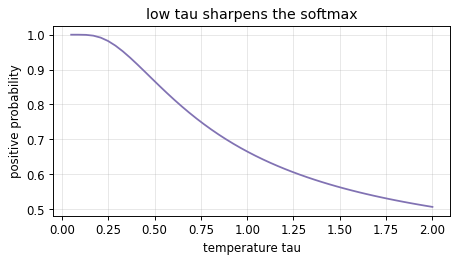

In [19]:
def infonce(scores, tau):
    z = np.array(scores)/tau; z = z - z.max()
    p = np.exp(z)/np.exp(z).sum()
    return p[0], -np.log(p[0])
for tau in [1.0, 0.5, 0.1]:
    p, l = infonce([2.0, 1.0, 0.0], tau)
    print(f"  tau={tau:<4}: positive prob {p:.3f},  loss {l:.2f}")
print("\nlower tau -> sharper: the positive's probability shoots up once it's ahead,")
print("and a CLOSE hard negative gets a much larger gradient (more pressure).")
taus = np.linspace(0.05, 2, 50)
plt.figure(figsize=(5.5,3.2)); plt.plot(taus, [infonce([2.0,1.0,0.0], t)[0] for t in taus], color=PURPLE)
plt.xlabel("temperature tau"); plt.ylabel("positive probability"); plt.title("low tau sharpens the softmax"); plt.show()

## Step 7 · In-batch negatives — the score **matrix**

The cheapest negatives are **free**: in a batch of B (query, positive) pairs, each query's
positive is the diagonal, and **every other pair's positive is a negative** for it. Build the
matrix `S[i,j] = sim(query_i, positive_j)`:

- **diagonal** `S[i,i]` = the correct match (should be **high**)
- **off-diagonal** `S[i,j]`, j≠i = in-batch negatives (should be **low**)

InfoNCE is then just **cross-entropy** on this matrix with labels `[0,1,2,...,B-1]` — "for row
i, pick column i." A batch of 128 gives every query 1 positive + 127 negatives for free, which
is why **bigger batches train better**.

score matrix S (rows=queries, cols=candidate positives):
[[ 0.15 -0.01 -0.54 -0.47 -0.4  -0.67 -0.2  -0.16]
 [ 0.12  0.28 -0.38 -0.27 -0.29 -0.44  0.05 -0.28]
 [ 0.32 -0.2   0.14 -0.22  0.09 -0.14 -0.18  0.06]
 [ 0.03  0.21 -0.38  0.14 -0.32 -0.09  0.13 -0.74]
 [ 0.08 -0.21 -0.04 -0.42  0.19 -0.35 -0.28  0.04]
 [ 0.23 -0.06 -0.08  0.08 -0.21  0.06  0.1  -0.34]
 [-0.08  0.05 -0.55 -0.23 -0.4  -0.43  0.19 -0.34]
 [-0.05 -0.34 -0.09 -0.56 -0.36 -0.1  -0.25  0.11]]

diagonal (correct) mean = 0.158   <- should be HIGH
off-diagonal (in-batch negatives) mean = -0.189   <- should be LOW
InfoNCE label for row i is exactly i (the diagonal).


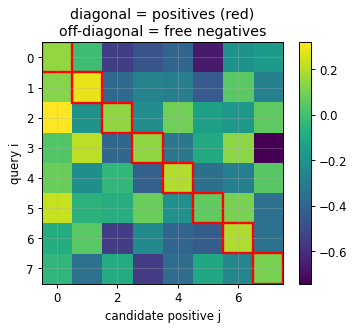

In [21]:
with torch.no_grad():
    B = 8
    qe, ie = qT(Q[:B]), iT(I[:B])
    qe = qe / qe.norm(dim=1, keepdim=True); ie = ie / ie.norm(dim=1, keepdim=True)
    S = (qe @ ie.T).numpy()
print("score matrix S (rows=queries, cols=candidate positives):")
print(np.round(S, 2))
print(f"\ndiagonal (correct) mean = {np.mean(np.diag(S)):.3f}   <- should be HIGH")
off = S[~np.eye(B, dtype=bool)]
print(f"off-diagonal (in-batch negatives) mean = {off.mean():.3f}   <- should be LOW")
print("InfoNCE label for row i is exactly i (the diagonal).")

fig, ax = plt.subplots(figsize=(4.6,4))
im = ax.imshow(S, cmap="viridis")
for i in range(B): ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor="red", lw=2))
ax.set_xlabel("candidate positive j"); ax.set_ylabel("query i")
ax.set_title("diagonal = positives (red)\noff-diagonal = free negatives"); fig.colorbar(im, fraction=0.046); plt.show()

### From the matrix to the loss (real numbers)

InfoNCE is **just cross-entropy on that matrix**. Take 3 pairs, divide by `τ`, softmax each
**row**, and the loss is `-log(diagonal probability)`. Here is every number.

In [23]:
Qv = np.array([[0.9,0.1],[0.1,0.9],[0.8,0.6]], dtype=float)    # 3 query vectors
Pv = np.array([[0.8,0.2],[0.2,0.8],[0.7,0.7]], dtype=float)    # 3 item vectors; pair i<->i are matches
Qn = Qv/np.linalg.norm(Qv,axis=1,keepdims=True); Pn = Pv/np.linalg.norm(Pv,axis=1,keepdims=True)
tau = 0.1
S3 = Qn @ Pn.T
print("S = queries . items^T :\n", S3.round(3))
print(f"\nS / tau  (tau={tau}) :\n", (S3/tau).round(2))
Z = S3/tau; Z = Z - Z.max(1, keepdims=True); P3 = np.exp(Z); P3 = P3/P3.sum(1, keepdims=True)
print("\nrow softmax (prob each query puts on each item) :\n", P3.round(3))
losses = [-np.log(P3[i, i]) for i in range(3)]
print(f"\nper-query loss  -log(diagonal prob) = {np.round(losses,3)}")
print(f"InfoNCE batch loss = mean = {np.mean(losses):.3f}   <- backprop minimizes THIS number")
print("row 2 has the highest loss: item0 (~0.31) steals probability from the correct item2 -> a hard negative.")

S = queries . items^T :
 [[0.991 0.348 0.781]
 [0.348 0.991 0.781]
 [0.922 0.776 0.99 ]]

S / tau  (tau=0.1) :
 [[9.91 3.48 7.81]
 [3.48 9.91 7.81]
 [9.22 7.76 9.9 ]]

row softmax (prob each query puts on each item) :
 [[0.89  0.001 0.109]
 [0.001 0.89  0.109]
 [0.311 0.073 0.616]]

per-query loss  -log(diagonal prob) = [0.117 0.117 0.484]
InfoNCE batch loss = mean = 0.239   <- backprop minimizes THIS number
row 2 has the highest loss: item0 (~0.31) steals probability from the correct item2 -> a hard negative.


### Train the dual encoder with in-batch InfoNCE

Now train for real: each batch builds the score matrix, divides by `τ`, and applies
cross-entropy against the diagonal labels. Then measure **recall@k**.

In [25]:
def train_infonce(tau=0.1, epochs=25, use_hard=False):
    torch.manual_seed(0)
    mrng = np.random.default_rng(123)                  # deterministic hard-negative mining
    qt, it = Tower(), Tower(); opt = torch.optim.Adam(list(qt.parameters())+list(it.parameters()), lr=0.01)
    B = 128
    for ep in range(epochs):
        perm = torch.randperm(len(Q))
        for k in range(0, len(Q), B):
            idx = perm[k:k+B]; qe, ie = qt(Q[idx]), it(I[idx])
            S = qe @ ie.T / tau; labels = torch.arange(len(idx))
            if use_hard:                                   # add one mined hard negative per query
                hard = []
                for j in idx.tolist():
                    cand = np.where(tpq == tpq[j])[0]; cand = cand[cand != j]   # same topic, not the positive
                    hard.append(mrng.choice(cand) if len(cand) else j)
                Sh = (qe * it(I[torch.tensor(hard)])).sum(1, keepdim=True) / tau
                S = torch.cat([S, Sh], dim=1)
            opt.zero_grad(); nn.functional.cross_entropy(S, labels).backward(); opt.step()
    with torch.no_grad(): return (qt(Qte) @ it(Ite).T).numpy()

def recall_at_k(S, k): return float(np.mean([r in np.argpartition(-S[r], k)[:k] for r in range(len(S))]))
S_easy = train_infonce()
for k in [1, 5, 10]:
    print(f"recall@{k:>2}: {recall_at_k(S_easy, k):.2f}")

recall@ 1: 0.43
recall@ 5: 0.84
recall@10: 0.95


## Step 8 · The collapse break-case

If the encoder maps **everything to nearly the same vector**, all scores in a row are similar,
the softmax can't put the positive above negatives, and retrieval fails. Contrastive learning
needs **alignment** (positives close) **and** spread (**uniformity**) — the M11 idea. We
simulate a collapsed encoder and watch recall crater.

recall@10  trained encoder : 0.95
recall@10  collapsed space : 0.01   <- can't separate anything


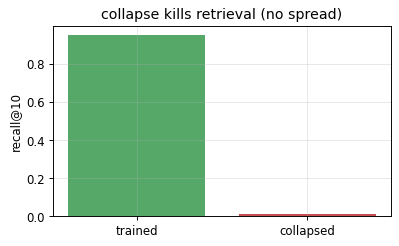

In [27]:
# collapsed: push all vectors to almost one direction
v = rng.normal(0, 1, D_raw)
Qc = torch.tensor((0.02*Qte.numpy() + v), dtype=torch.float32)
Ic = torch.tensor((0.02*Ite.numpy() + v), dtype=torch.float32)
collapsed = (Qc @ Ic.T).numpy()
print(f"recall@10  trained encoder : {recall_at_k(S_easy,10):.2f}")
print(f"recall@10  collapsed space : {recall_at_k(collapsed,10):.2f}   <- can't separate anything")
plt.figure(figsize=(4.8,3)); plt.bar(["trained","collapsed"], [recall_at_k(S_easy,10), recall_at_k(collapsed,10)], color=[GREEN, RED])
plt.ylabel("recall@10"); plt.title("collapse kills retrieval (no spread)"); plt.show()

---
# Part B · Hard negatives & fine-tuning

## Step 9 · Triplet loss — a margin between positive and negative

An alternative to the softmax: a **triplet** (anchor query `q`, positive `p`, negative `n`)
with a **margin** `m`. Loss is zero **only** when the positive beats the negative by at least
`m`:
$$\mathcal{L}=\max(0,\; m + s(q,n) - s(q,p))$$
InfoNCE (Step 5) is the many-negatives generalization of this one-positive-one-negative form.

s(q,p)=3.0, s(q,n)=2.8, margin 0.5 -> 0.3  (still work to do)
s(q,p)=3.0, s(q,n)=0.2, margin 0.5 -> 0.0  (easy neg -> 0 loss, teaches little)


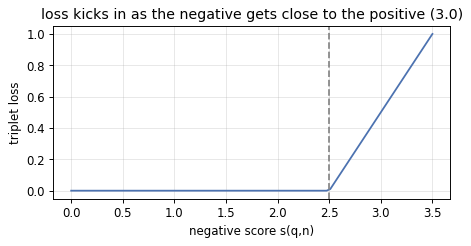

In [30]:
def triplet(s_qp, s_qn, m=0.5): return max(0.0, m + s_qn - s_qp)
print("s(q,p)=3.0, s(q,n)=2.8, margin 0.5 ->", round(triplet(3.0, 2.8), 2), " (still work to do)")
print("s(q,p)=3.0, s(q,n)=0.2, margin 0.5 ->", round(triplet(3.0, 0.2), 2), " (easy neg -> 0 loss, teaches little)")
sn = np.linspace(0, 3.5, 100)
plt.figure(figsize=(5.5,3)); plt.plot(sn, [triplet(3.0, x) for x in sn], color=BLUE)
plt.axvline(2.5, color=GRAY, ls="--"); plt.xlabel("negative score s(q,n)"); plt.ylabel("triplet loss")
plt.title("loss kicks in as the negative gets close to the positive (3.0)"); plt.show()

## Step 10 · Why hard negatives raise the gradient

In the softmax, a negative with a **high score** contributes a large term to the denominator,
**stealing probability** from the positive and keeping the loss (and gradient) high. Easy
negatives contribute almost nothing. Example: positive 3.0, easy 0.2, **hard 2.8**.

positive probability WITH hard negative : 0.53 -> loss 0.63
positive probability WITHOUT it          : 0.94 -> loss 0.06
that gap (0.53 vs 0.94) is the training signal a hard negative provides.


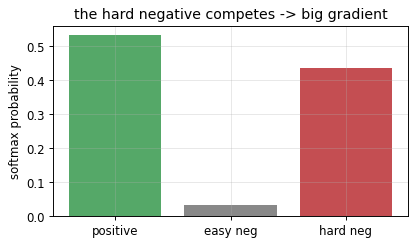

In [32]:
def softmax(x): x = x - x.max(); return np.exp(x)/np.exp(x).sum()
with_hard    = softmax(np.array([3.0, 0.2, 2.8]))
without_hard = softmax(np.array([3.0, 0.2]))
print("positive probability WITH hard negative :", round(with_hard[0], 2), "-> loss", round(-np.log(with_hard[0]),2))
print("positive probability WITHOUT it          :", round(without_hard[0], 2), "-> loss", round(-np.log(without_hard[0]),2))
plt.figure(figsize=(5,3)); plt.bar(["positive","easy neg","hard neg"], with_hard, color=[GREEN, GRAY, RED])
plt.ylabel("softmax probability"); plt.title("the hard negative competes -> big gradient"); plt.show()
print("that gap (0.53 vs 0.94) is the training signal a hard negative provides.")

## Step 11 · How you actually **mine** hard negatives (the pipeline)

You don't guess hard negatives — you let the **current model** surface them, then **filter**.
The real loop:

```
1. Train a first-pass encoder (in-batch negatives only).
2. ENCODE the whole corpus  -> vectors -> ANN index (M13).
3. For each query, RETRIEVE top-k with the current model.
4. PICK the high-ranked items that are NOT the labeled positive  = hard negatives
   (they look right to the model but are wrong).
5. FILTER likely FALSE negatives: drop candidates scoring within a margin of the
   positive (those may be true matches that just aren't labeled).
6. RETRAIN with these hard negatives added; optionally re-mine (ANCE-style).
```

We run one query through steps 2–5 on a small corpus and watch which candidates are **kept** vs
**filtered**.

labeled positive id=0  score=0.997  (rank 2)
top-8 retrieved:
   id   2  score 0.998  topic 0  same-topic
   id   1  score 0.998  topic 0  same-topic
   id   0  score 0.997  topic 0  <-POSITIVE
   id 299  score 0.984  topic 0  same-topic
   id 183  score 0.983  topic 0  same-topic
   id  78  score 0.978  topic 0  same-topic
   id 201  score 0.971  topic 0  same-topic
   id  13  score 0.961  topic 0  same-topic

filter: drop candidates scoring within 0.03 of the positive (0.997):
   DROPPED (too similar -> maybe true match): [2, 1, 299, 183, 78, 201]
   KEPT hard negatives:                       [13, 211, 104, 43, 271, 77, 156, 133]
   => kept 18 usable hard negatives, filtered 6 risky ones.


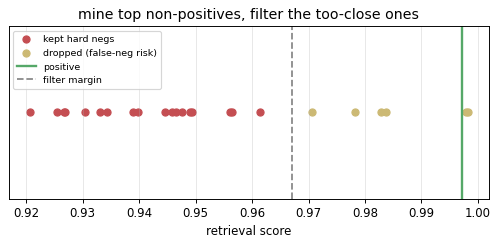

In [34]:
# small corpus with topics; the labeled positive sits in the query's topic
mr = np.random.default_rng(1); d = 8; Tt = 6; Nc = 300
ctr = mr.normal(0,1,(Tt,d))*2.0
it_t = mr.integers(0,Tt,Nc); corp = ctr[it_t] + mr.normal(0,0.6,(Nc,d))
qtopic = 0
qv = ctr[qtopic] + mr.normal(0,0.2,d)
corp[0] = qv + mr.normal(0,0.15,d); it_t[0] = qtopic          # true positive: close to query
corp[1] = qv + mr.normal(0,0.12,d); it_t[1] = qtopic          # near-duplicate (likely FALSE neg)
corp[2] = qv + mr.normal(0,0.13,d); it_t[2] = qtopic          # near-duplicate (likely FALSE neg)
corp = corp/np.linalg.norm(corp,axis=1,keepdims=True); qv = qv/np.linalg.norm(qv)
pos_id = 0

scores = corp @ qv                                            # step 3: retrieve by current model
ranked = np.argsort(-scores)
print(f"labeled positive id={pos_id}  score={scores[pos_id]:.3f}  (rank {list(ranked).index(pos_id)})")
print("top-8 retrieved:")
for r in ranked[:8]:
    tag = "<-POSITIVE" if r==pos_id else ("same-topic" if it_t[r]==qtopic else "diff-topic")
    print(f"   id {r:3d}  score {scores[r]:.3f}  topic {it_t[r]}  {tag}")

hard = [r for r in ranked[:25] if r != pos_id]                # step 4: high-ranked non-positives
margin = 0.03                                                 # step 5: filter likely false negatives
kept    = [r for r in hard if scores[r] <  scores[pos_id]-margin]
dropped = [r for r in hard if scores[r] >= scores[pos_id]-margin]
print(f"\nfilter: drop candidates scoring within {margin} of the positive ({scores[pos_id]:.3f}):")
print(f"   DROPPED (too similar -> maybe true match): {dropped[:8]}")
print(f"   KEPT hard negatives:                       {kept[:8]}")
print(f"   => kept {len(kept)} usable hard negatives, filtered {len(dropped)} risky ones.")

plt.figure(figsize=(6,3))
plt.scatter([scores[r] for r in kept],   [1]*len(kept),   color=RED,  label="kept hard negs")
plt.scatter([scores[r] for r in dropped],[1]*len(dropped),color=GOLD, label="dropped (false-neg risk)")
plt.axvline(scores[pos_id], color=GREEN, lw=2, label="positive")
plt.axvline(scores[pos_id]-margin, color=GRAY, ls="--", label="filter margin")
plt.yticks([]); plt.xlabel("retrieval score"); plt.legend(fontsize=8); plt.title("mine top non-positives, filter the too-close ones"); plt.show()

## Step 12 · Mining hard negatives improves fine-grained recall

Random/in-batch negatives are usually **easy** (different topic) — they teach broad separation
but leave the model fuzzy **within** a topic. Adding **mined hard negatives** (same-topic, not
the positive) forces the model to separate look-alikes, so **fine-grained recall (recall@1)
rises.**

                  recall@1  recall@5  recall@10
  easy negs only      0.43      0.84       0.95
     + hard negs      0.55      0.92       0.98
biggest gain is at recall@1 (the hardest, most fine-grained rank).


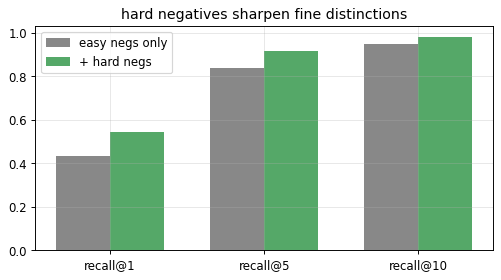

In [36]:
S_easy = train_infonce(use_hard=False)
S_hard = train_infonce(use_hard=True)
print(f"{'':>16}{'recall@1':>10}{'recall@5':>10}{'recall@10':>11}")
print(f"{'easy negs only':>16}{recall_at_k(S_easy,1):>10.2f}{recall_at_k(S_easy,5):>10.2f}{recall_at_k(S_easy,10):>11.2f}")
print(f"{'+ hard negs':>16}{recall_at_k(S_hard,1):>10.2f}{recall_at_k(S_hard,5):>10.2f}{recall_at_k(S_hard,10):>11.2f}")
ks = [1,5,10]
xb = np.arange(len(ks)); w = 0.35
plt.figure(figsize=(6,3.4))
plt.bar(xb-w/2, [recall_at_k(S_easy,k) for k in ks], w, color=GRAY, label="easy negs only")
plt.bar(xb+w/2, [recall_at_k(S_hard,k) for k in ks], w, color=GREEN, label="+ hard negs")
plt.xticks(xb, [f"recall@{k}" for k in ks]); plt.legend(); plt.title("hard negatives sharpen fine distinctions"); plt.show()
print("biggest gain is at recall@1 (the hardest, most fine-grained rank).")

## Step 13 · The catch — false negatives

A mined "hard negative" must **actually be negative**. Two valid items for one query look like a
hard pair; treating one as a negative teaches the model to **separate valid matches** — damaging
the encoder. So mine hard negatives, then **filter** likely false negatives (labels, business
rules, a cross-encoder), and validate false-negative-heavy slices.

In [38]:
miners = pd.DataFrame({
    "miner": ["BM25 (lexical)", "current model", "other retrieval model", "cross-encoder", "human/model filter"],
    "finds": ["same words, wrong meaning", "close in vector space, wrong attribute",
              "audience overlap, wrong content", "text matches but a rule forbids it", "removes accepted alternates"],
})
print(miners.to_string(index=False))
print("\ngood batch = easy negs (stability) + filtered hard negs (discrimination).")
print("bad batch  = treat every unclicked plausible item as negative -> false negatives.")

                miner                                  finds
       BM25 (lexical)              same words, wrong meaning
        current model close in vector space, wrong attribute
other retrieval model        audience overlap, wrong content
        cross-encoder     text matches but a rule forbids it
   human/model filter            removes accepted alternates

good batch = easy negs (stability) + filtered hard negs (discrimination).
bad batch  = treat every unclicked plausible item as negative -> false negatives.


## Step 14 · End-to-end encoder fine-tuning recipe

Putting it together — how you actually **fine-tune a text encoder** with a contrastive
objective + hard negatives. The mindset: you **start from a pretrained encoder** that already
"knows language" and **reshape its vector space** so *your* notion of relevant lines up. You do
**not** train from scratch.

```
1. START from a pretrained encoder (E5 / IRPS / BERT).       # don't start from zero
2. Add POOL + NORMALIZE on top -> the sentence vector (Step 2).
3. For each batch of (query, positive) pairs [+ mined hard negs]:
     - encode both sides
     - build the in-batch score matrix / tau          (Step 6)
     - InfoNCE cross-entropy, labels = diagonal
     - backprop, update the encoder weights
4. Use a BIG batch (more in-batch negatives = better); grad-cache if memory-bound.
5. EVAL on retrieval metrics (recall@k / nDCG) on held-out data, not just loss.
6. (Optional) do a MINING round (Step 10) and continue training.
```

Below is that loop in miniature: we "warm-start" from the Step-6 encoder, then continue training
**with mined hard negatives** and confirm held-out recall@1 improves — i.e. fine-tuning moved
the geometry in the right direction.

fine-tuning progress (held-out recall@1):
  after warm start (easy negs)    : recall@1 = 0.397
  after round 1 (+ hard negs)     : recall@1 = 0.514
  after round 2 (+ hard negs)     : recall@1 = 0.526


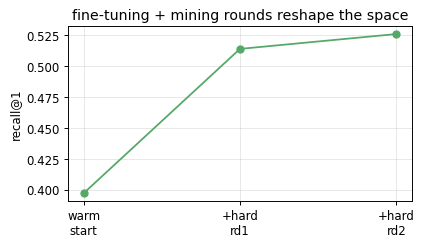

In [40]:
# a compact fine-tuning loop: warm-start a fresh encoder, then adapt with hard negatives.
def finetune(rounds=2, epochs=8, tau=0.1, mine=True):
    torch.manual_seed(1); mrng = np.random.default_rng(7)
    qt, it = Tower(), Tower()
    opt = torch.optim.Adam(list(qt.parameters())+list(it.parameters()), lr=0.01)
    hist = []
    for rd in range(rounds):
        for ep in range(epochs):
            perm = torch.randperm(len(Q)); Bt = 128
            for k in range(0, len(Q), Bt):
                idx = perm[k:k+Bt]; qe, ie = qt(Q[idx]), it(I[idx])
                S = qe @ ie.T / tau; labels = torch.arange(len(idx))
                if mine and rd > 0:                            # round 0 = warm start; then mine
                    hard = []
                    for j in idx.tolist():
                        cand = np.where(tpq == tpq[j])[0]; cand = cand[cand != j]
                        hard.append(mrng.choice(cand) if len(cand) else j)
                    Sh = (qe * it(I[torch.tensor(hard)])).sum(1, keepdim=True) / tau
                    S = torch.cat([S, Sh], dim=1)
                opt.zero_grad(); nn.functional.cross_entropy(S, labels).backward(); opt.step()
        with torch.no_grad(): Ste = (qt(Qte) @ it(Ite).T).numpy()
        r1 = recall_at_k(Ste, 1); hist.append(r1)
        stage = "warm start (easy negs)" if rd == 0 else f"round {rd} (+ hard negs)"
        print(f"  after {stage:26}: recall@1 = {r1:.3f}")
    return hist

print("fine-tuning progress (held-out recall@1):")
hist = finetune(rounds=3, epochs=8)
plt.figure(figsize=(5,3)); plt.plot(range(len(hist)), hist, "o-", color=GREEN)
plt.xticks(range(len(hist)), ["warm\nstart","+hard\nrd1","+hard\nrd2"]); plt.ylabel("recall@1")
plt.title("fine-tuning + mining rounds reshape the space"); plt.show()

## Step 15 · Evaluating on held-out data — recall@k and nDCG

You never judge an encoder on the queries it trained on (it could just memorize). You keep a
**held-out set**: labeled queries **set aside and never trained on**, used only to measure. E.g.
10,000 labeled queries → **train on 9,000, hold out 1,000**; report metrics on the 1,000.

Two metrics, worked on one query with graded relevance (`2`=great, `1`=ok, `0`=irrelevant):
- **recall@k** — of all relevant items, how many landed in the top-k? ("did we *find* them?")
- **nDCG@k** — reward relevant items ranked **early**, via a `1/log2(rank+1)` discount, then
  normalize by the best-possible ordering. ("did we *order* them well?")

model ranking : ['d1', 'd2', 'd3', 'd4', 'd5']
true relevance: [0, 2, 0, 1, 0]  (2=great, 1=ok, 0=irrelevant)

  recall@1 = 0/2 = 0.00
  recall@3 = 1/2 = 0.50
  recall@5 = 2/2 = 1.00

  DCG@5  = 2/log2(3) + 1/log2(5) = 1.693
  IDCG@5 = ideal [2,1,0,0,0]      = 2.631
  nDCG@5 = DCG/IDCG = 0.643   (1.0 = perfect ordering)

You compute both PER held-out query, then AVERAGE across the whole held-out set.


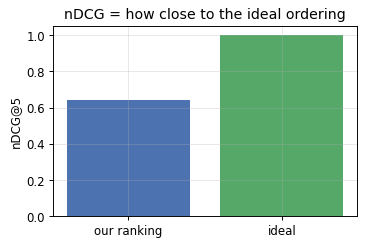

In [42]:
# one held-out query: the model's ranking + the TRUE relevance of each returned item
ranked = ["d1", "d2", "d3", "d4", "d5"]
rel    = {"d1": 0, "d2": 2, "d3": 0, "d4": 1, "d5": 0}     # ground-truth labels (held-out)
rels   = [rel[x] for x in ranked]
print("model ranking :", ranked)
print("true relevance:", rels, " (2=great, 1=ok, 0=irrelevant)\n")

# recall@k : relevant = rel>0 ; here d2,d4 are relevant -> 2 total
total_rel = sum(1 for v in rel.values() if v > 0)
for k in [1, 3, 5]:
    found = sum(1 for x in ranked[:k] if rel[x] > 0)
    print(f"  recall@{k} = {found}/{total_rel} = {found/total_rel:.2f}")

# nDCG@k : DCG = sum rel/log2(rank+1) ; IDCG = DCG of the ideal order ; nDCG = DCG/IDCG
def dcg(vals, k): return sum(r/np.log2(i+2) for i, r in enumerate(vals[:k]))
k = 5
DCG  = dcg(rels, k)
IDCG = dcg(sorted(rel.values(), reverse=True), k)          # ideal order [2,1,0,0,0]
print(f"\n  DCG@{k}  = 2/log2(3) + 1/log2(5) = {DCG:.3f}")
print(f"  IDCG@{k} = ideal [2,1,0,0,0]      = {IDCG:.3f}")
print(f"  nDCG@{k} = DCG/IDCG = {DCG/IDCG:.3f}   (1.0 = perfect ordering)")
print("\nYou compute both PER held-out query, then AVERAGE across the whole held-out set.")

# bar chart: our ranking's nDCG vs the ideal
plt.figure(figsize=(4.4,3)); plt.bar(["our ranking","ideal"], [DCG/IDCG, 1.0], color=[BLUE, GREEN])
plt.ylim(0,1.05); plt.ylabel(f"nDCG@{k}"); plt.title("nDCG = how close to the ideal ordering"); plt.show()

---
## Recap — the M14 toolkit

**Encoders (Part A).** A **sentence encoder** is *text → tokens → transformer → **pool** →
**normalize*** → one vector (what M11 stores, M13 indexes); **E5** adds `query:/passage:`
prefixes, **IRPS** is LinkedIn's in-house version. A **dual encoder = two-tower = bi-encoder**:
query and item embedded **separately** (score = dot), so item vectors **precompute & index** for
retrieval. A **cross-encoder** reads the pair **jointly** — more accurate but **O(pairs)**, so
it's used to **rerank** the top-K from the dual encoder (**retrieve → rerank**). **InfoNCE**
makes the positive win a softmax; **temperature τ** controls sharpness; **in-batch negatives**
are the off-diagonal of the query×item **score matrix** (labels = the diagonal). A **collapsed**
space can't separate anything — you need **alignment + uniformity** (M11).

**Hard negatives & fine-tuning (Part B).** **Triplet loss** enforces a margin between one
positive and one negative; InfoNCE generalizes it to many. A **hard negative** competes in the
softmax → **raises the gradient** and teaches fine distinctions. You **mine** them with a real
pipeline — **encode → retrieve → pick top non-positives → filter false negatives** — then
**retrain** (optionally re-mine, ANCE-style). **Fine-tuning** = start from a **pretrained**
encoder, add pool+normalize, train InfoNCE with big batches + mined hard negatives, and **eval
on recall@k** — reshaping the geometry so retrieval lands the right items.

**Where this connects:** M14 is *how* the encoders behind M11 embeddings and M12/M13 retrieval
are trained; its retrieve→rerank and hard-negative discipline are what make the candidate sets
good enough for the downstream ranker.